In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
df = pd.read_csv('data/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# **Data Description**

- **country**: Name of the country.
- **child_mort**: Death of children under 5 years of age per 1000 live births.
- **exports**: Exports of goods and services per capita. Given as %age of the GDP per capita.
- **health**: Total health spending per capita. Given as %age of GDP per capita.
- **imports**: Imports of goods and services per capita. Given as %age of the GDP per capita.
- **income**: Net income per person.
- **inflation**: The measurement of the annual growth rate of the Total GDP.
- **life_expec**: The average number of years a new born child would live if the current mortality patterns are to remain the same.
- **total_fer**: The number of children that would be born to each woman if the current age-fertility rates remain the same.
- **gdpp**: The GDP per capita. Calculated as the Total GDP divided by the total population.

In [4]:
df.shape

(167, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# **Data Visualisation**

### **a) Income**

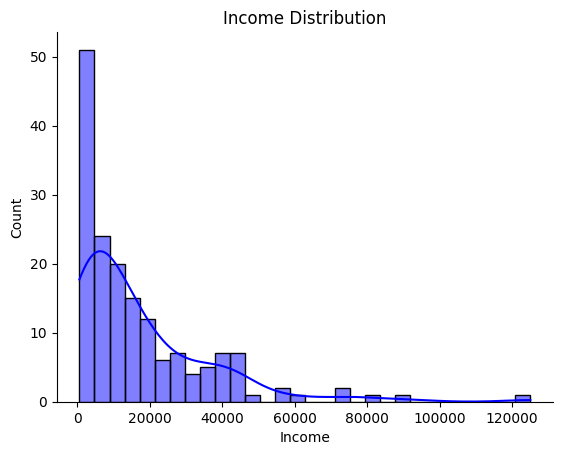

In [8]:
sns.histplot(data=df, x='income', kde=True, bins=30, color='blue')
plt.title('Income Distribution')
plt.xlabel('Income')
sns.despine()
plt.show()

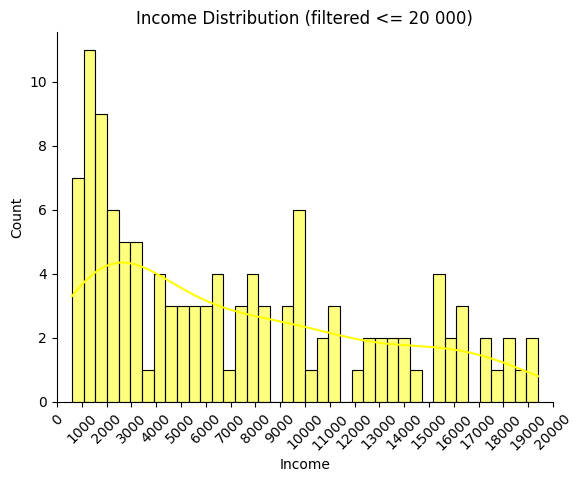

In [9]:
df_filtered = df[df['income'] <= 20000]

sns.histplot(data=df_filtered, x='income', kde=True, bins=40, color='yellow')
plt.title('Income Distribution (filtered <= 20 000)')
plt.xlabel('Income')
plt.xticks(range(0,21000,1000), rotation=45)
plt.xlim(0,20000)
sns.despine()
plt.show()

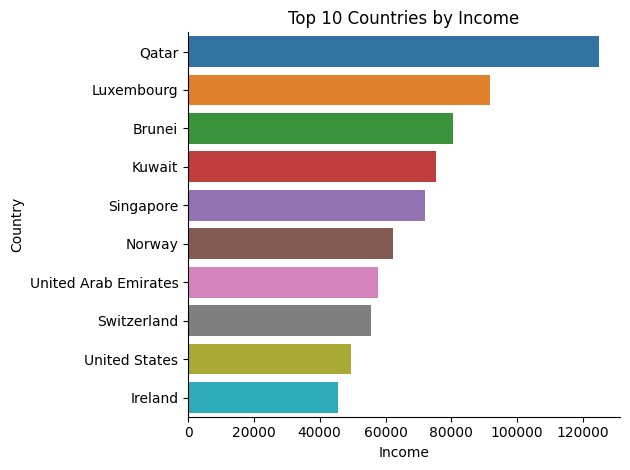

In [10]:
top_countries = df.sort_values(by='income', ascending=False).head(10)

sns.barplot(data=top_countries, y='country', x='income', ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Countries by Income')
plt.ylabel('Country')
plt.xlabel('Income')
plt.tight_layout()
sns.despine()
plt.show()

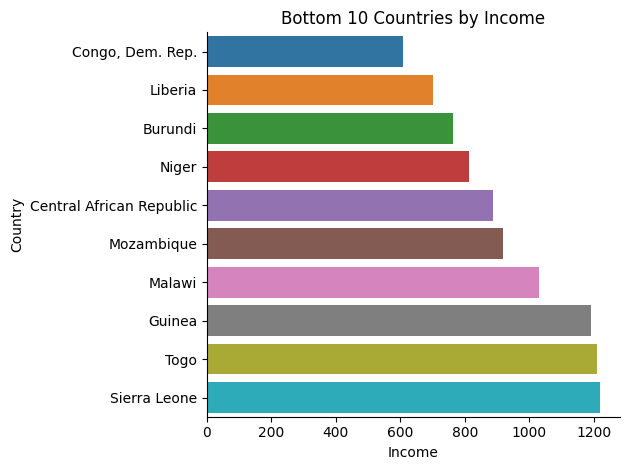

In [11]:
bottom10 = df.sort_values(by='income', ascending=True).head(10)

sns.barplot(data=bottom10, x='income', y='country', ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Bottom 10 Countries by Income')
plt.xlabel('Income')
plt.ylabel('Country')
plt.tight_layout()
sns.despine()
plt.show()

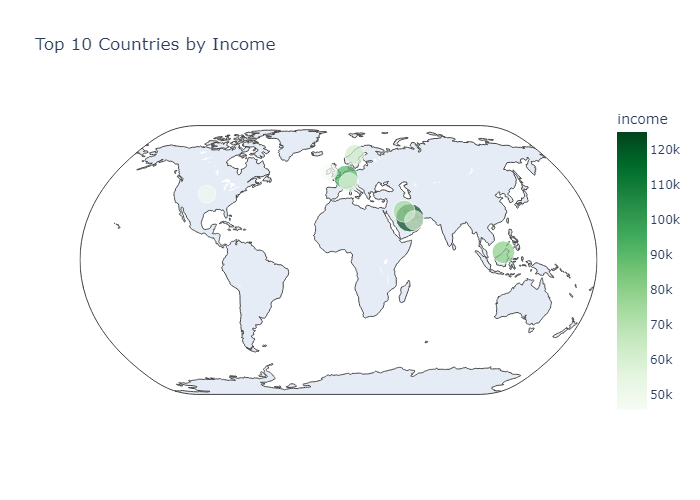

In [12]:
import plotly.express as px
from IPython.display import Image

top10 = df.nlargest(10, 'income')
fig = px.scatter_geo(top10, locations='country', locationmode='country names',
                     size='income', color='income', color_continuous_scale='Greens',
                     hover_name='country',
                     projection='natural earth', title='Top 10 Countries by Income')

fig.write_image('images/top_income_countries.png')
display(Image(filename='images/top_income_countries.png'))

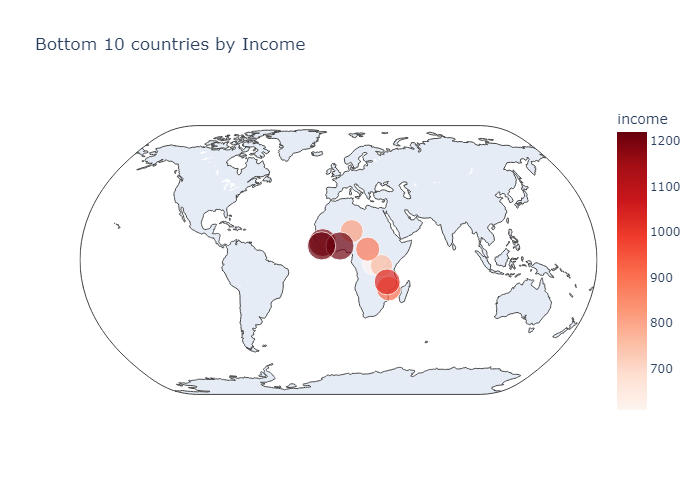

In [13]:
bottom10 = df.nsmallest(10, 'income')

fig= px.scatter_geo(bottom10, locations='country', locationmode='country names',
                    size='income', color='income', color_continuous_scale='Reds',
                    hover_name='country', projection='natural earth', title='Bottom 10 countries by Income')
fig.write_image('images/bottom_income_countries.png')
display(Image(filename='images/bottom_income_countries.png'))

### **b) Life Expectancy**

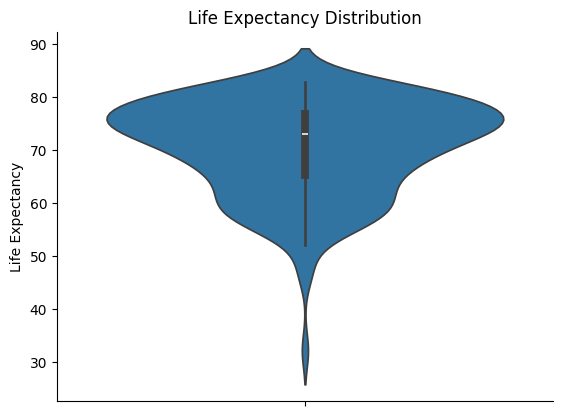

In [14]:
sns.violinplot(data=df, y='life_expec')
plt.title('Life Expectancy Distribution')
plt.ylabel('Life Expectancy')
sns.despine()
plt.show()

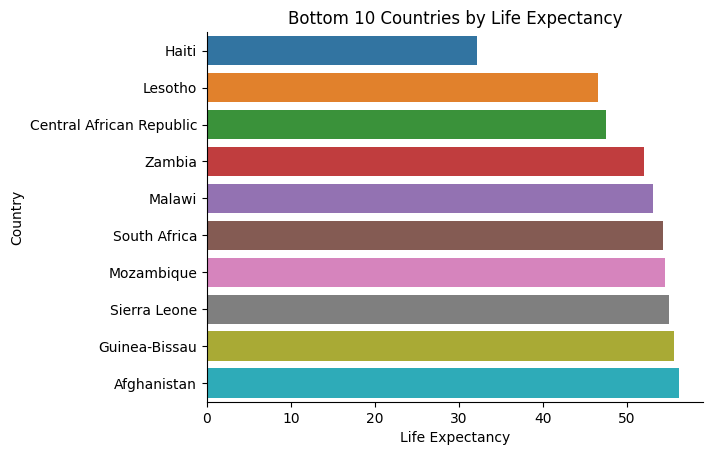

In [15]:
bottom10 = df.sort_values(by='life_expec', ascending=True).head(10)

sns.barplot(data=bottom10, x='life_expec', y='country', ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Bottom 10 Countries by Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Country')
sns.despine()
plt.show()

### **c) Health**

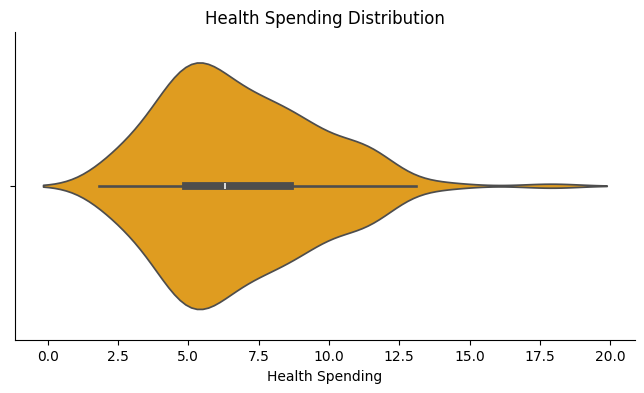

In [16]:
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='health', color='orange')
plt.title('Health Spending Distribution')
plt.xlabel('Health Spending')
sns.despine()
plt.show()

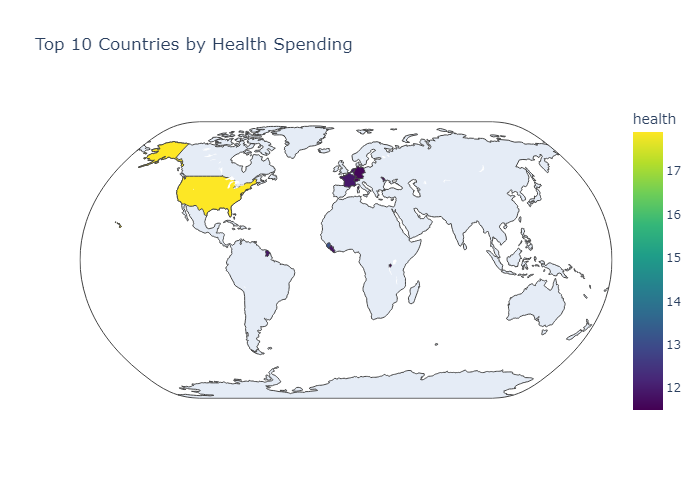

In [17]:
top10 = df.nlargest(10, 'health')

fig = px.choropleth(top10, locations='country', locationmode='country names',
                     color='health', color_continuous_scale='Viridis',
                     hover_name='country', projection='natural earth', title='Top 10 Countries by Health Spending')
fig.write_image('images/top_health_countries.png')
display(Image(filename='images/top_health_countries.png'))

In [18]:
top10[['country', 'health']]

,country,health
159,United States,17.9
101,"Micronesia, Fed. Sts.",14.2
132,Sierra Leone,13.1
54,France,11.9
110,Netherlands,11.9
88,Liberia,11.8
102,Moldova,11.7
26,Burundi,11.6
58,Germany,11.6
145,Switzerland,11.5


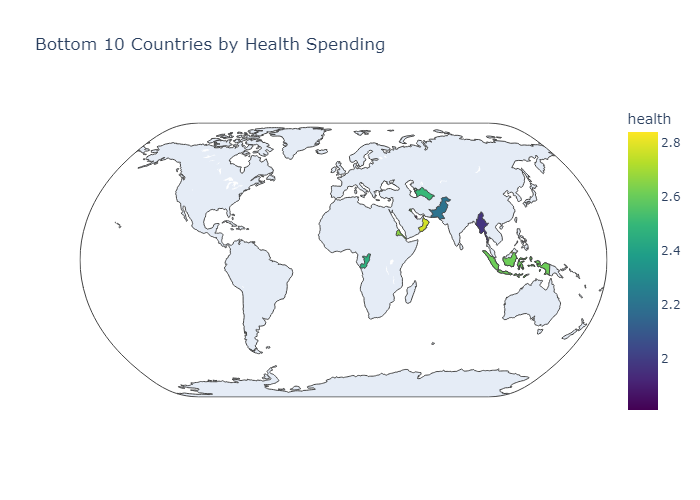

In [19]:
bottom10 = df.nsmallest(10, 'health')

fig = px.choropleth(bottom10, locations='country', locationmode='country names',
                     color='health', color_continuous_scale='Viridis',
                     hover_name='country', projection='natural earth', title='Bottom 10 Countries by Health Spending')
fig.write_image('images/bottom_health_countries.png')
display(Image(filename='images/bottom_health_countries.png'))

In [138]:
bottom10[['country', 'health']]

,country,health
123,Qatar,1.81
107,Myanmar,1.97
116,Pakistan,2.20
38,"Congo, Rep.",2.46
154,Turkmenistan,2.50
70,Indonesia,2.61
82,Kuwait,2.63
50,Eritrea,2.66
115,Oman,2.77
23,Brunei,2.84


### **d) Total Fertility and Child Mortality**

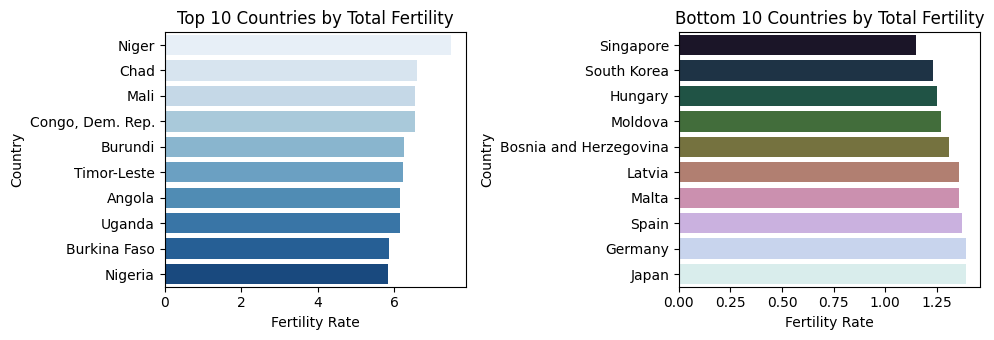

In [139]:
top10fer = df.nlargest(10, 'total_fer')
bottom10fer = df.nsmallest(10, 'total_fer')

fig, axes = plt.subplots(1, 2, figsize=(10,3.5))

sns.barplot(data=top10fer, y='country', x='total_fer', ci=None, palette='Blues', ax=axes[0])
axes[0].set_title('Top 10 Countries by Total Fertility')
axes[0].set_ylabel('Country')
axes[0].set_xlabel('Fertility Rate')

sns.barplot(data=bottom10fer, y='country', x='total_fer', ci=None, palette='cubehelix', ax=axes[1])
axes[1].set_title('Bottom 10 Countries by Total Fertility')
axes[1].set_ylabel('Country')
axes[1].set_xlabel('Fertility Rate')

plt.tight_layout()
plt.show()

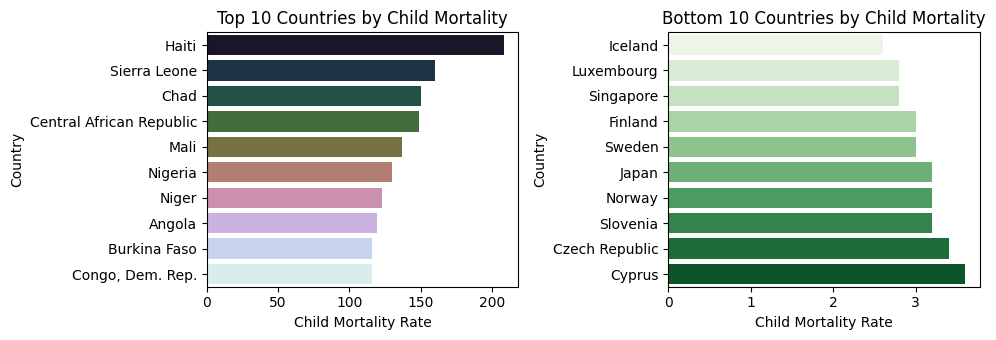

In [140]:
top10mor = df.nlargest(10, 'child_mort')
bottom10mor = df.nsmallest(10, 'child_mort')

fig, axes = plt.subplots(1, 2, figsize=(10,3.5))

sns.barplot(data=top10mor, y='country', x='child_mort', ci=None, palette='cubehelix', ax=axes[0])
axes[0].set_title('Top 10 Countries by Child Mortality')
axes[0].set_ylabel('Country')
axes[0].set_xlabel('Child Mortality Rate')

sns.barplot(data=bottom10mor, y='country', x='child_mort', ci=None, palette='Greens', ax=axes[1])
axes[1].set_title('Bottom 10 Countries by Child Mortality')
axes[1].set_ylabel('Country')
axes[1].set_xlabel('Child Mortality Rate')

plt.tight_layout()
plt.show()

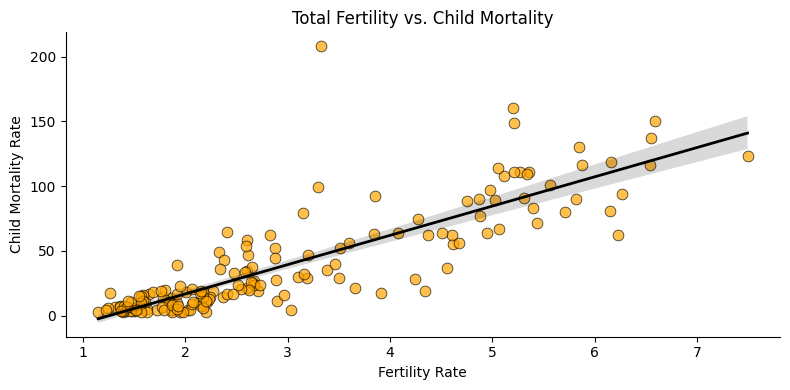

In [141]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='total_fer', y='child_mort', color='orange', s=60, edgecolor='k', alpha=0.7)
sns.regplot(data=df, x='total_fer', y='child_mort', scatter=False, line_kws={'color': 'black', 'linewidth': 2})
plt.title('Total Fertility vs. Child Mortality')
plt.xlabel('Fertility Rate')
plt.ylabel('Child Mortality Rate')
sns.despine()
plt.tight_layout()
plt.show()

### **c) Economic Indicators**

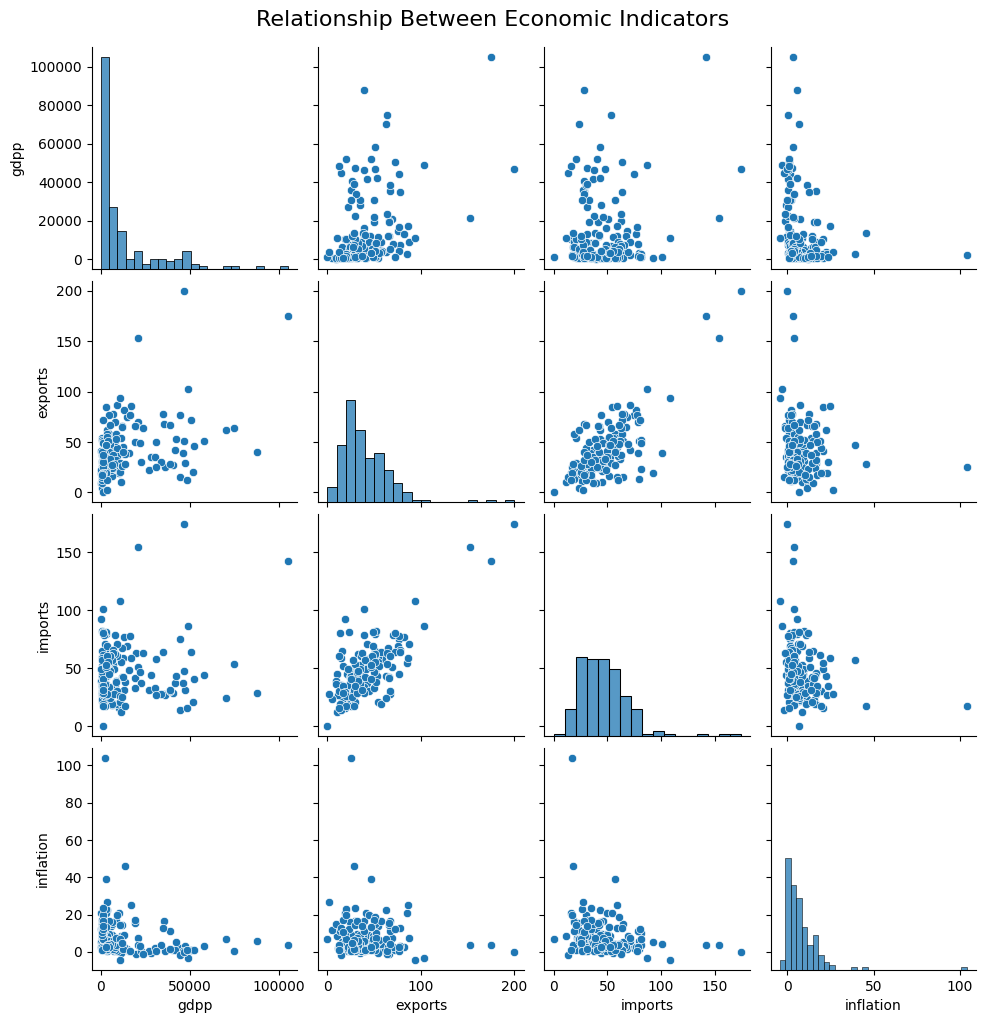

In [142]:
g = sns.pairplot(df[['gdpp', 'exports', 'imports', 'inflation']], kind='scatter')
g.fig.suptitle('Relationship Between Economic Indicators', y=1.02, fontsize=16)
plt.show()

### **e) Correlation Between All Features**

<AxesSubplot: >

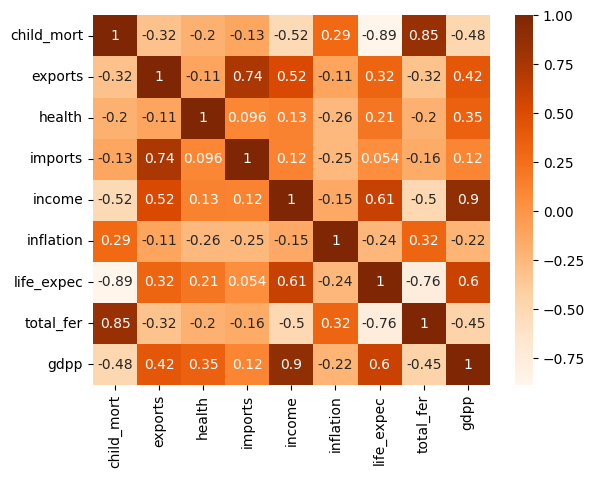

In [143]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Oranges')

### Conclusion of the Data Analysis:

The analysis shows that higher **child mortality** is linked to higher **total fertility**, indicating that families tend to have more children where child survival is less certain. Countries with higher **exports** also have higher **imports** and **income**, reflecting stronger economic activity. **GDP** and **income** are positively correlated with **life expectancy**, while lower **life expectancy** is associated with higher **child mortality** and **fertility rates**. Additionally, there is a slight trend where increased **income** corresponds to lower **total fertility** and **child mortality**, likely due to improved healthcare and living standards.

# **Modelling**

### **1. KMeans**

In [197]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df.drop('country', axis=1)
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])
model.fit(X)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

In [198]:
clusters = model.predict(X)
df['cluster'] = clusters

In [199]:
for cluster_num, group in df.groupby('cluster'):
    print(f'Cluster {cluster_num}:')
    print(group['country'].tolist())
    print()

Cluster 0:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1:
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'T

**Principal Component Analysis:**

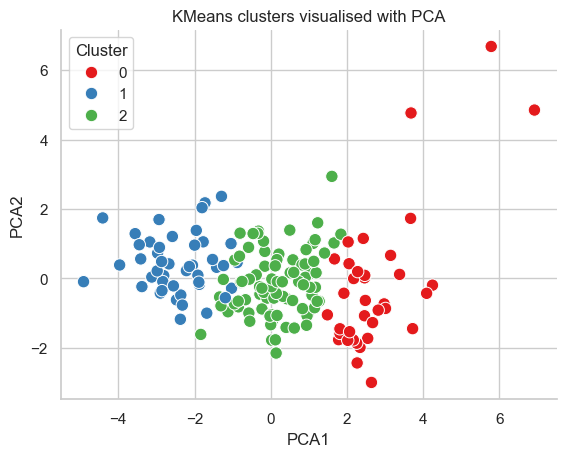

In [200]:
from sklearn.decomposition import PCA

feature_columns = df.drop(['country', 'cluster'], axis=1).columns.tolist()
X_scaled = StandardScaler().fit_transform(df[feature_columns])

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
df_pca['cluster'] = df['cluster']
df_pca['country'] = df['country']

sns.set_style('whitegrid')
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='cluster', palette='Set1', s=80)
plt.title('KMeans clusters visualised with PCA')
plt.legend(title='Cluster')
sns.despine()
plt.show()

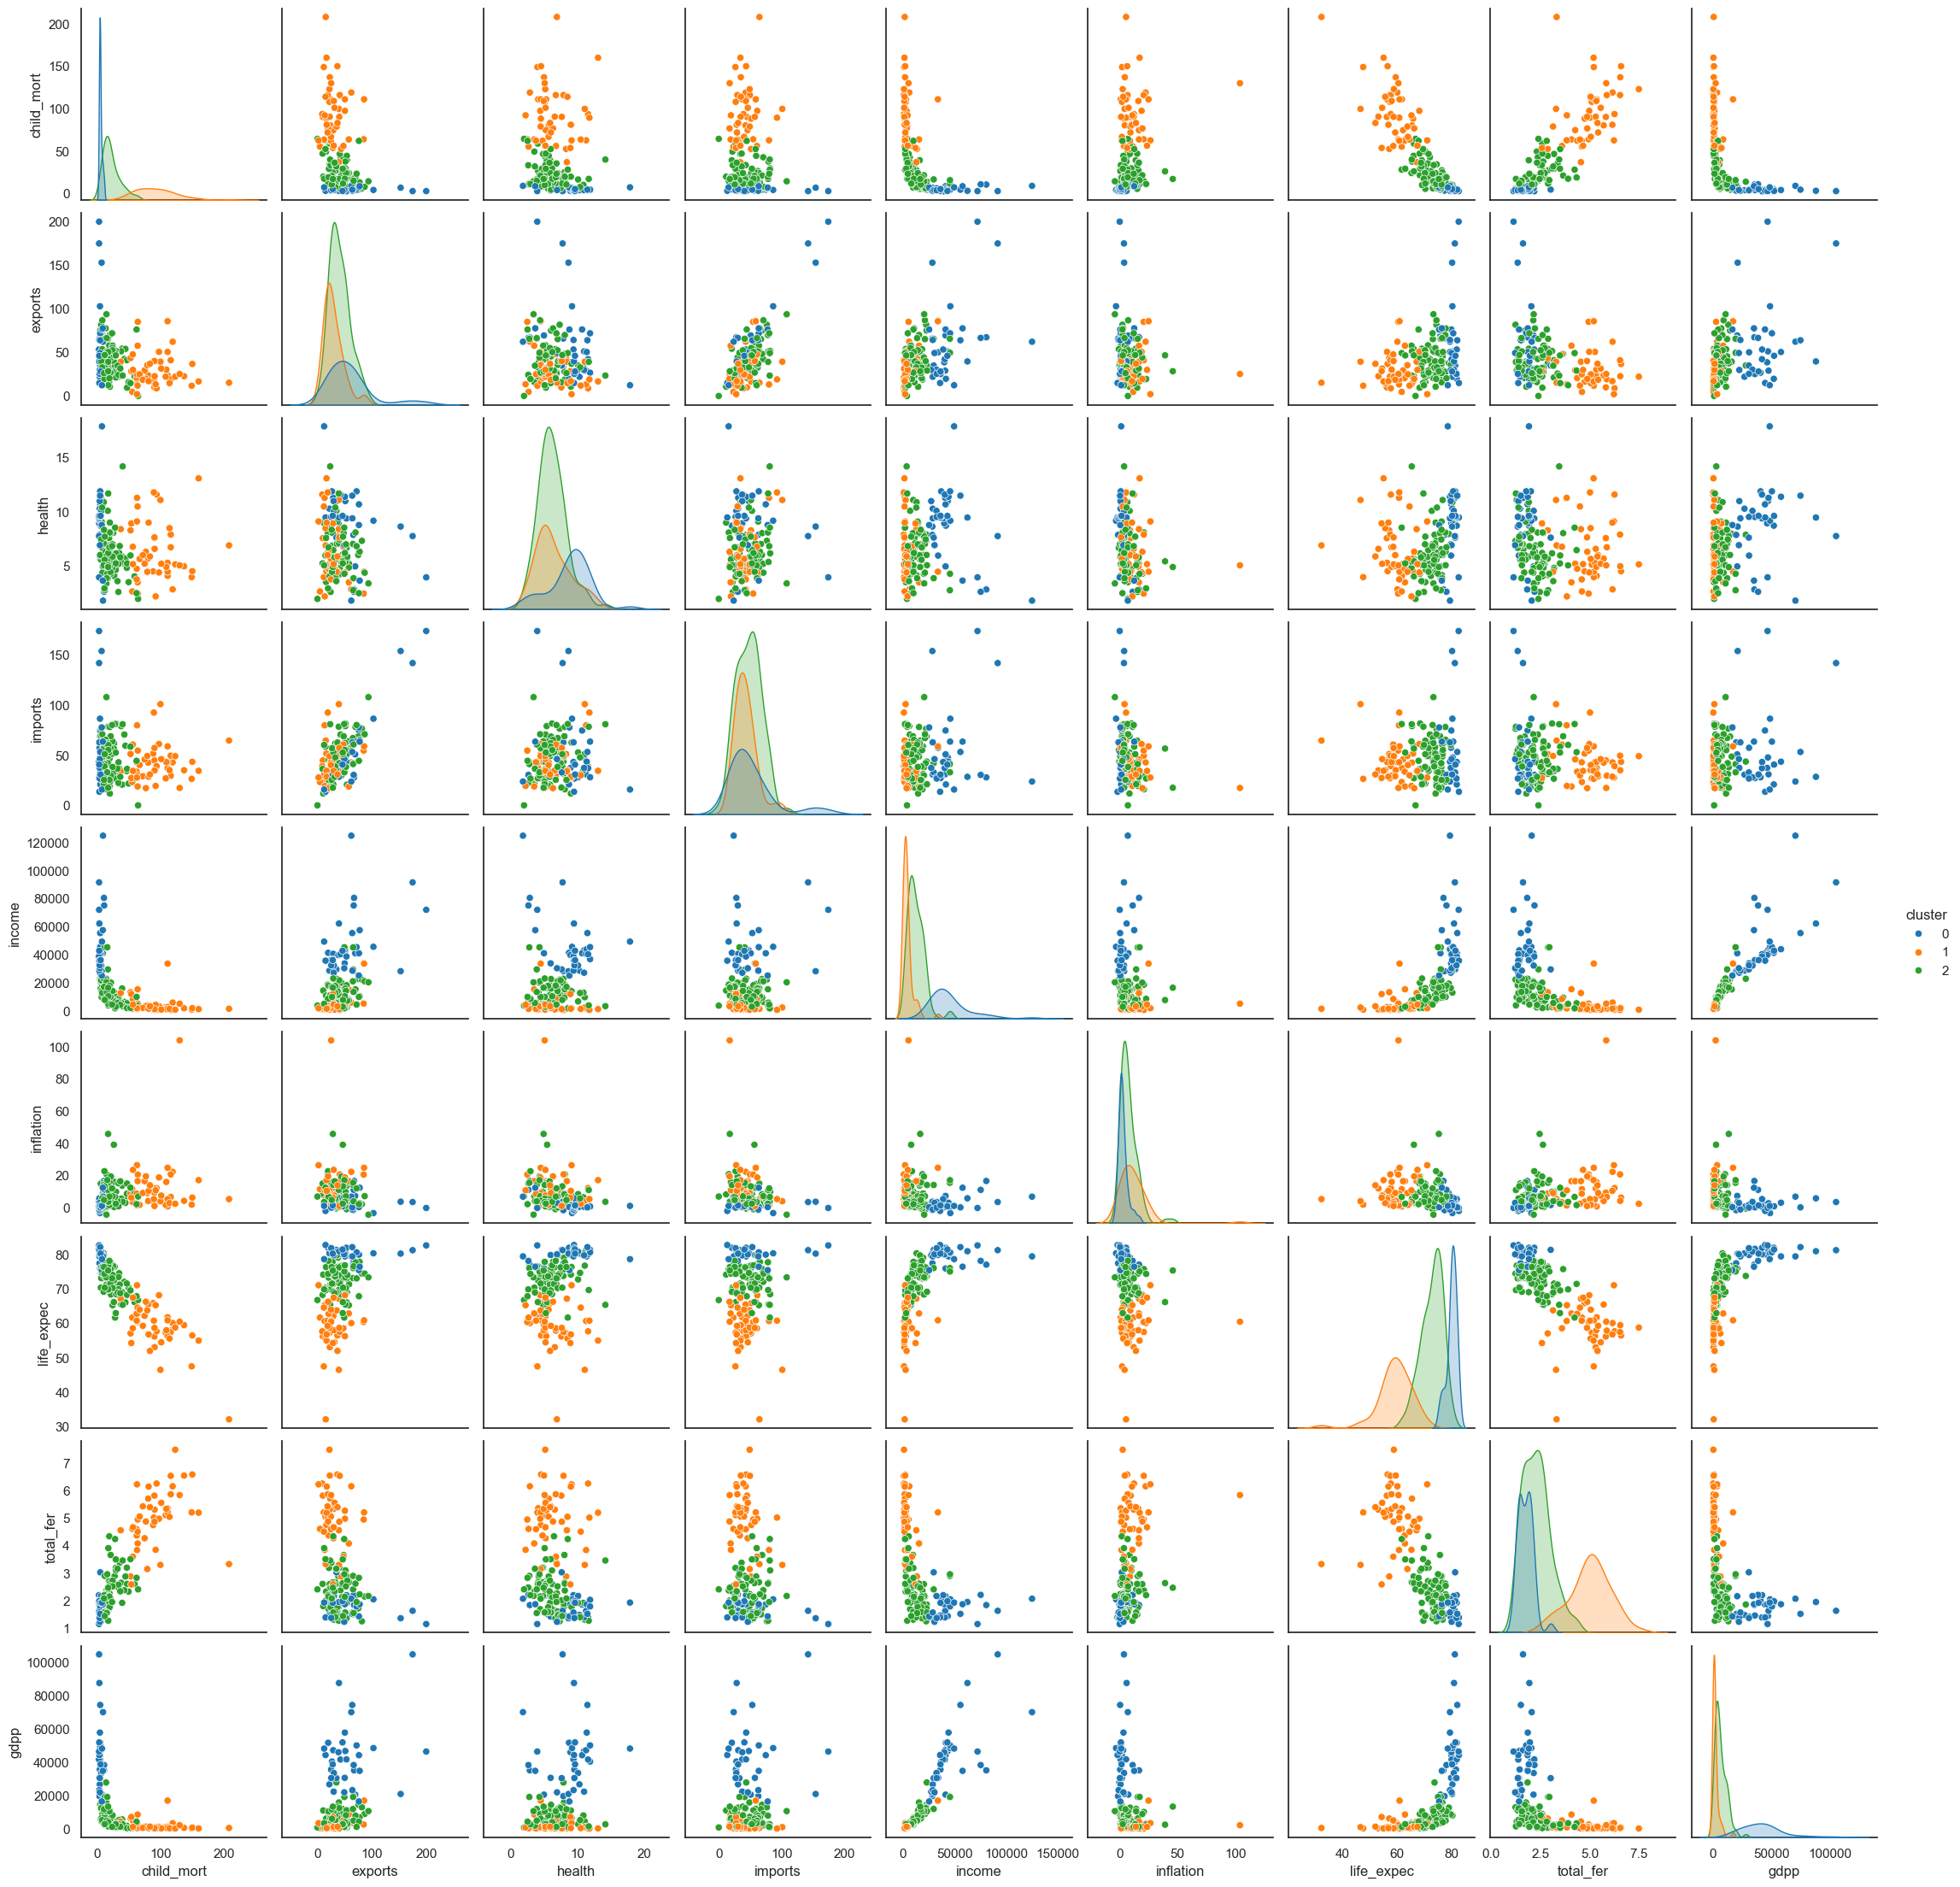

In [192]:
sns.pairplot(df.drop('country', axis=1), hue="cluster", palette="tab10")

From what we see, we can name the clusters as:
- 0 = developed countries
- 1 = least developing countries
- 2 = developing countries

In [201]:
labels = {0: 'Developed Countries', 1: 'Least Developing Countries', 2: 'Developing Countries'}
order_map = {'Developed Countries': 0, 'Developing Countries': 1, 'Least Developing Countries': 2}

df['cluster_label'] = df['cluster'].map(labels)
df['cluster_order'] = df['cluster_label'].map(order_map)

In [202]:
result = df.drop('country', axis=1).groupby(['cluster_label']).median()
result = result.sort_values('cluster_order')
result = result.drop(['cluster', 'cluster_order'], axis=1)
result

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster_label,,,,,,,,,
Developed Countries,4.20,50.35,9.445,39.05,40550.0,1.190,80.35,1.815,41200.0
Developing Countries,18.35,37.30,5.930,48.65,10180.0,5.805,73.60,2.235,4670.0
Least Developing Countries,90.20,23.80,5.660,40.30,1870.0,8.920,59.50,5.060,897.0


**Searching for Important Features:**

In [205]:
from scipy.stats import f_oneway

df = df.drop(['cluster_label', 'cluster_order'], axis=1)
for col in feature_columns:
    groups = [df[df['cluster'] == c][col] for c in df['cluster'].unique()]
    stat, p = f_oneway(*groups)
    print(f"{col}: p = {p:.4f}")

child_mort: p = 0.0000
exports: p = 0.0000
health: p = 0.0000
imports: p = 0.2217
income: p = 0.0000
inflation: p = 0.0002
life_expec: p = 0.0000
total_fer: p = 0.0000
gdpp: p = 0.0000


**Import** doesn’t seem to be an important feature.

**Evaluation of the model:**

In [206]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_scaled = model.named_steps['scaler'].fit_transform(X)
labels = model.named_steps['kmeans'].labels_

score = silhouette_score(X_scaled, labels)
db_index = davies_bouldin_score(X_scaled, labels)
ch_index = calinski_harabasz_score(X_scaled, labels)

print(f'Silhouette score: {score:.2f}')
print(f'Davies-Bouldin Index: {db_index:.2f}')
print(f'Calinski-Harabasz Index: {ch_index:.2f}')

Silhouette score: 0.28
Davies-Bouldin Index: 1.28
Calinski-Harabasz Index: 66.23


**Trying to find the best n of clusters:**

In [207]:
range_n_clusters = range(2, 7)

sil_scores = []
db_scores = []
ch_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, cluster_labels)
    db = davies_bouldin_score(X_scaled, cluster_labels)
    ch = calinski_harabasz_score(X_scaled, cluster_labels)

    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

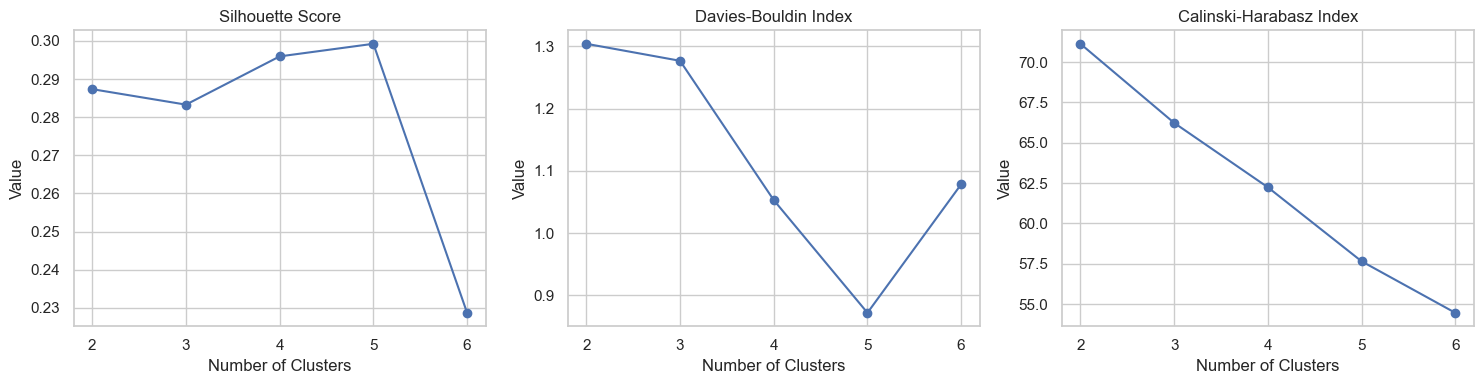

In [208]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(range_n_clusters, sil_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Value')

plt.subplot(1, 3, 2)
plt.plot(range_n_clusters, db_scores, marker='o')
plt.title('Davies-Bouldin Index')
plt.xlabel('Number of Clusters')
plt.ylabel('Value')

plt.subplot(1, 3, 3)
plt.plot(range_n_clusters, ch_scores, marker='o')
plt.title('Calinski-Harabasz Index')
plt.xlabel('Number of Clusters')
plt.ylabel('Value')

plt.tight_layout()
plt.show()

**Elbow method:**

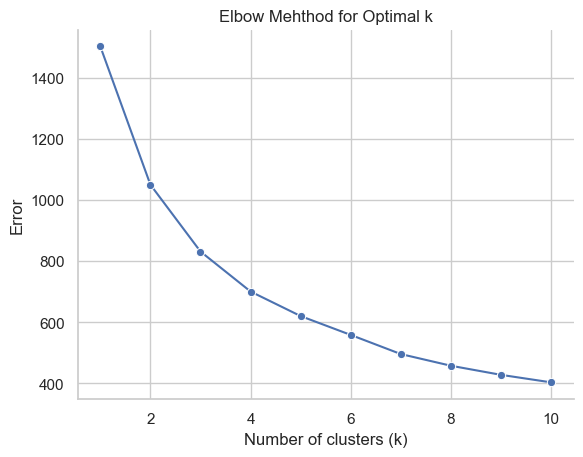

In [209]:
errors = []
cluster_range = range(1,11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    errors.append(kmeans.inertia_)

sns.lineplot(x=cluster_range, y=errors, marker='o')
plt.title('Elbow Mehthod for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Error')
sns.despine()
plt.show()

In [210]:
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])
model.fit(X)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=5, random_state=42))])

In [211]:
clusters = model.predict(X)
df['cluster'] = clusters

In [212]:
for cluster_num, group in df.groupby('cluster'):
    print(f'Cluster {cluster_num}:')
    print(group['country'].tolist())
    print()

Cluster 0:
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'India', 'Indonesia', 'Iran', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Myanmar', 'Nepal', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Samoa', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Slovak Republic', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Suriname', 'Tajikistan', 'Thailand', 'Tonga', 'Tunisia', 'Turkey', 'Turkmenistan', 'Ukrain

**When using more than 3 clusters, there are more outliers. So, with K-Means, I choose 3 clusters.**

### **2. Gaussian Mixture Model**

In [213]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=3, random_state=42)

In [214]:
clusters = gmm.predict(X_scaled)
df['cluster'] = clusters

for cluster_num, group in df.groupby('cluster'):
    print(f'Cluster {cluster_num}:')
    print(group['country'].to_list())
    print()

Cluster 0:
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Bahamas', 'Barbados', 'Belarus', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Georgia', 'Grenada', 'Hungary', 'Indonesia', 'Iran', 'Jamaica', 'Kazakhstan', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Montenegro', 'Morocco', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Romania', 'Russia', 'Serbia', 'Seychelles', 'Slovak Republic', 'St. Vincent and the Grenadines', 'Suriname', 'Thailand', 'Tunisia', 'Turkey', 'Ukraine', 'Uruguay', 'Venezuela']

Cluster 1:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway

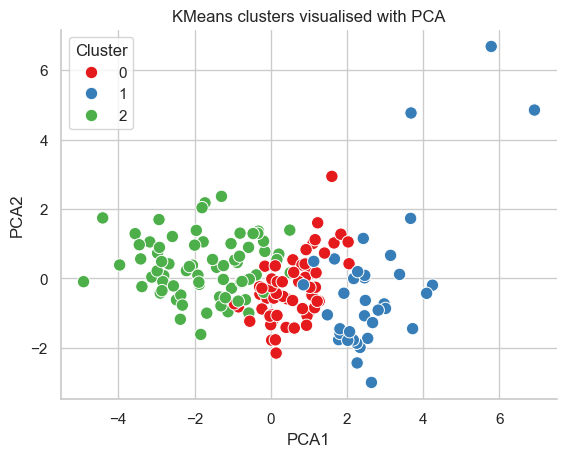

In [217]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
df_pca['cluster'] = df['cluster']
df_pca['country'] = df['country']

sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='cluster', palette='Set1', s=80)
plt.title('KMeans clusters visualised with PCA')
plt.legend(title='Cluster')
sns.despine()
plt.show()

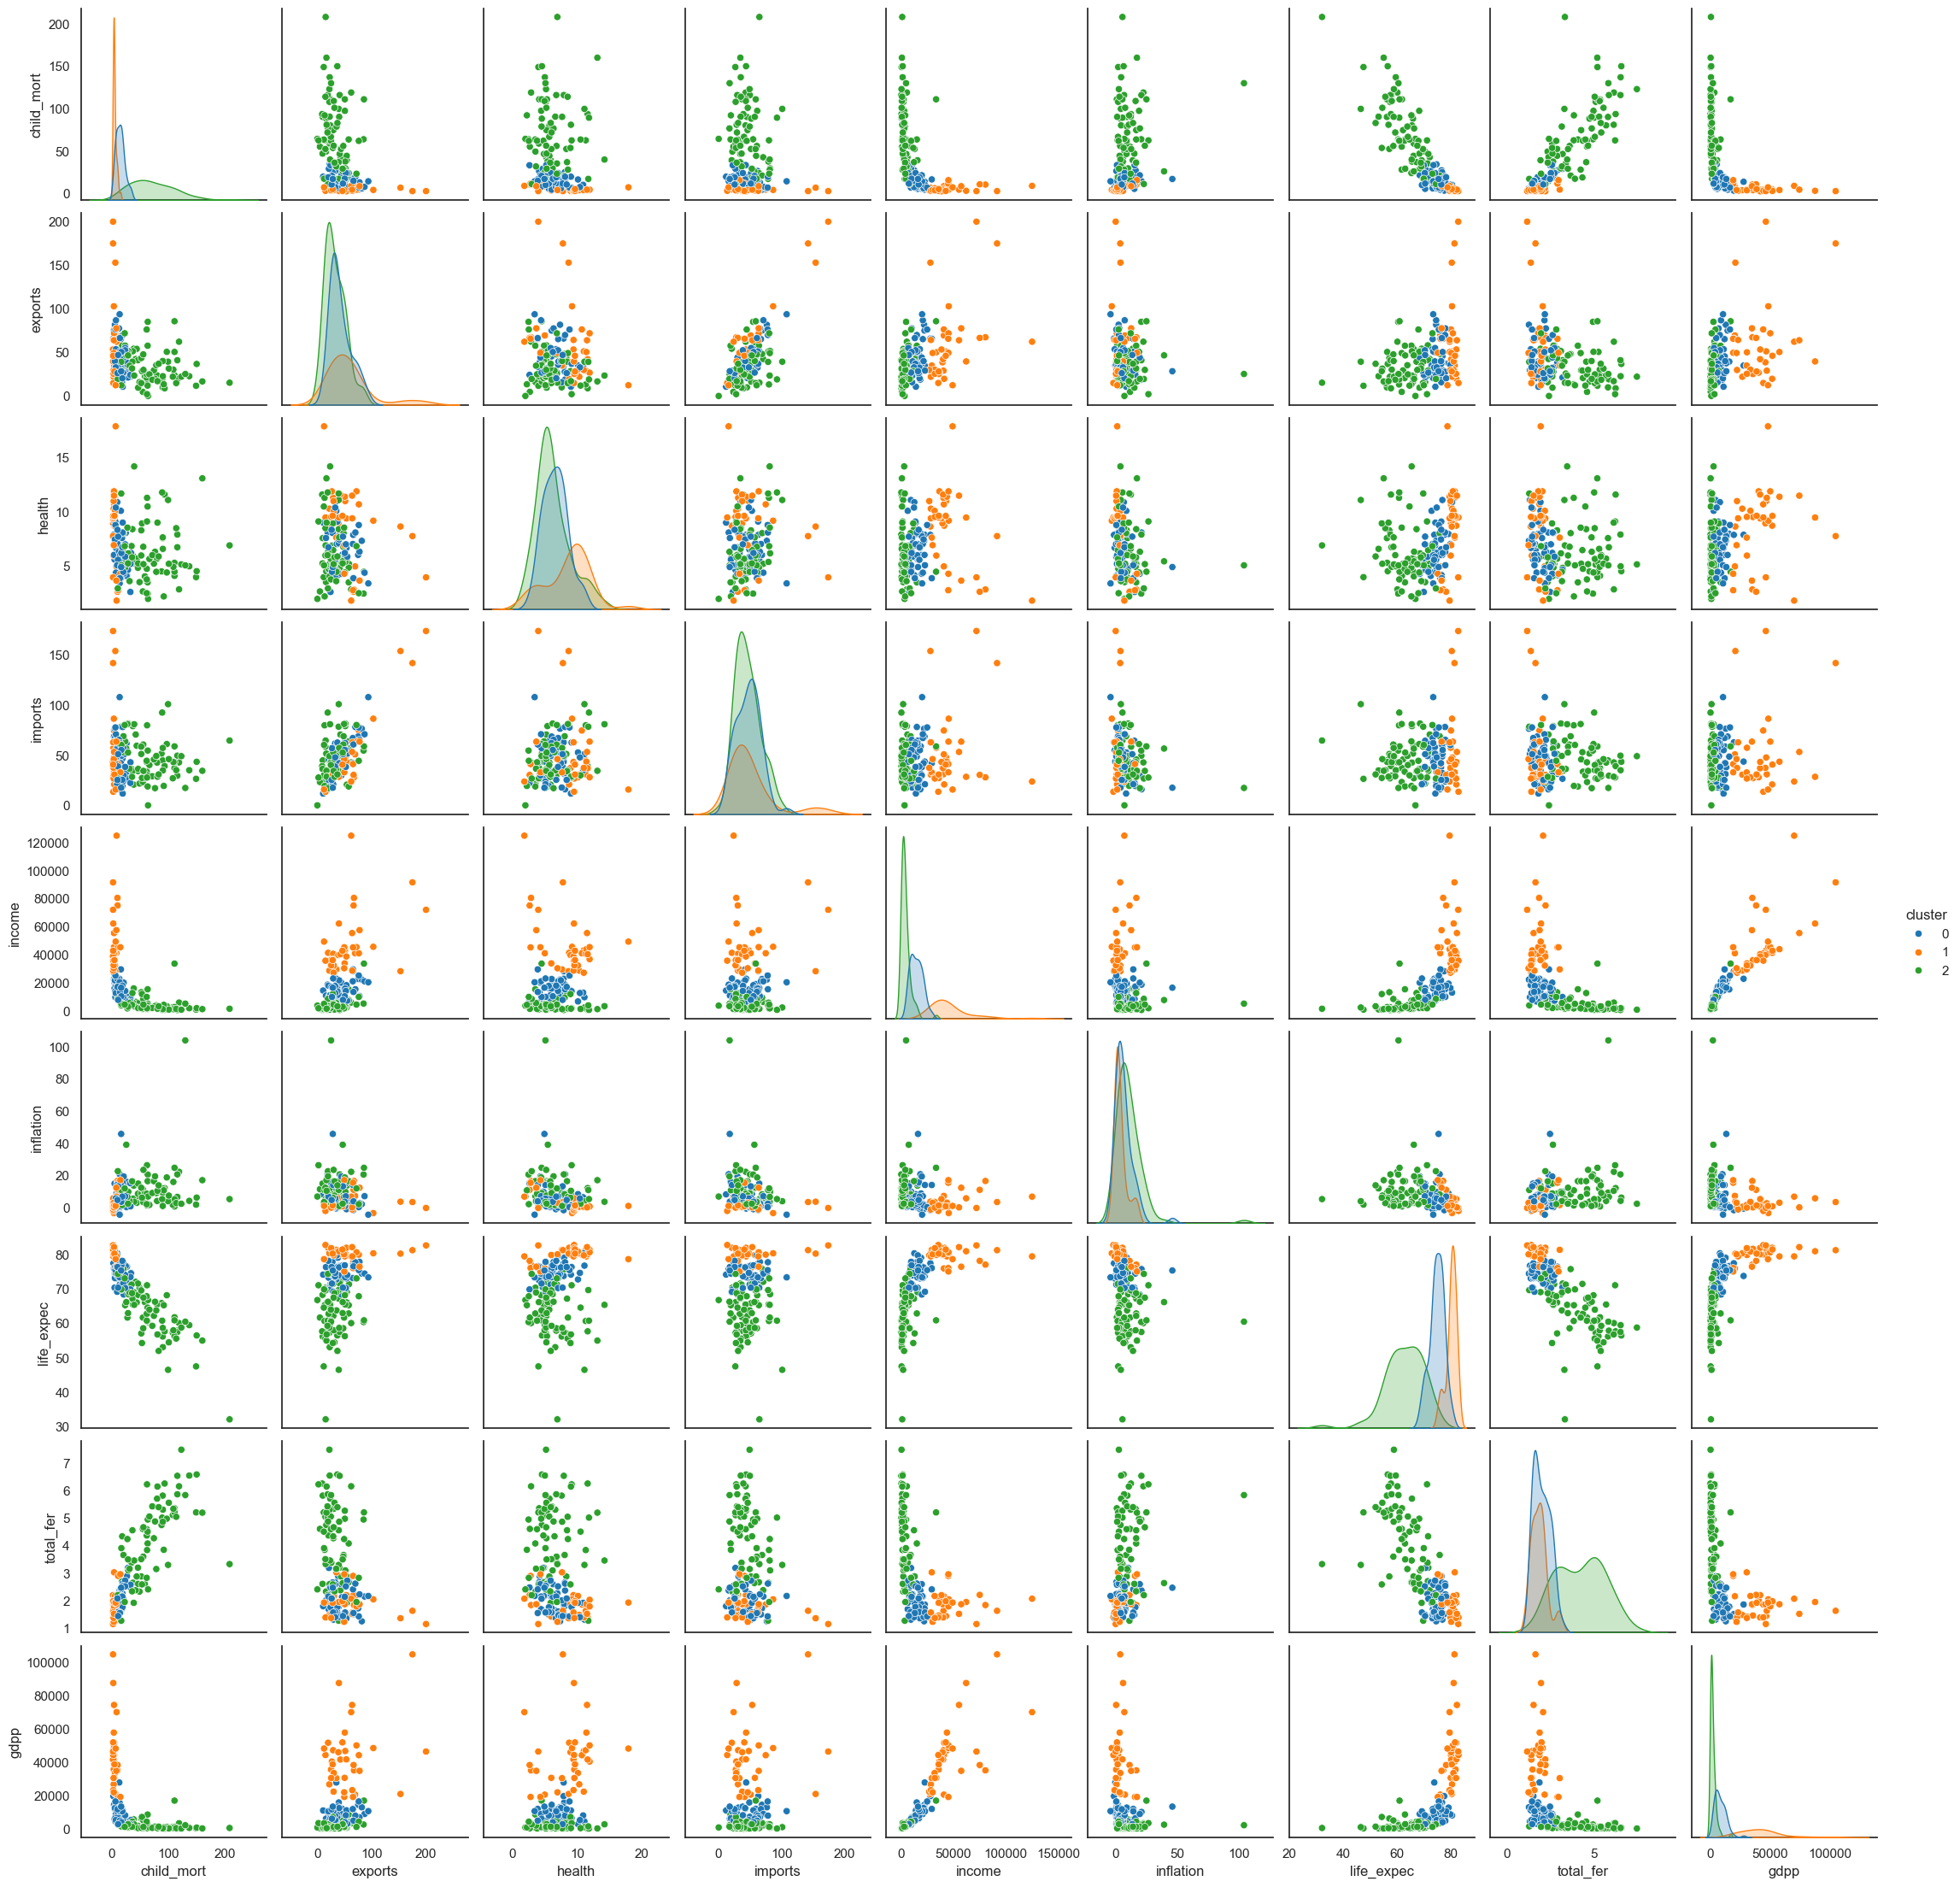

In [218]:
sns.set_style('white')
sns.pairplot(df.drop('country', axis=1), hue='cluster', palette='tab10')

In [219]:
score = silhouette_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_scaled, clusters)
ch_index = calinski_harabasz_score(X_scaled, clusters)

print(f'Silhouette Score: {score:.2f}')
print(f'Davies-Bouldin Index: {db_index:.2f}')
print(f'Calinski-Harabasz Index: {ch_index:.2f}')

Silhouette Score: 0.19
Davies-Bouldin Index: 1.41
Calinski-Harabasz Index: 54.36


# Model Comparison

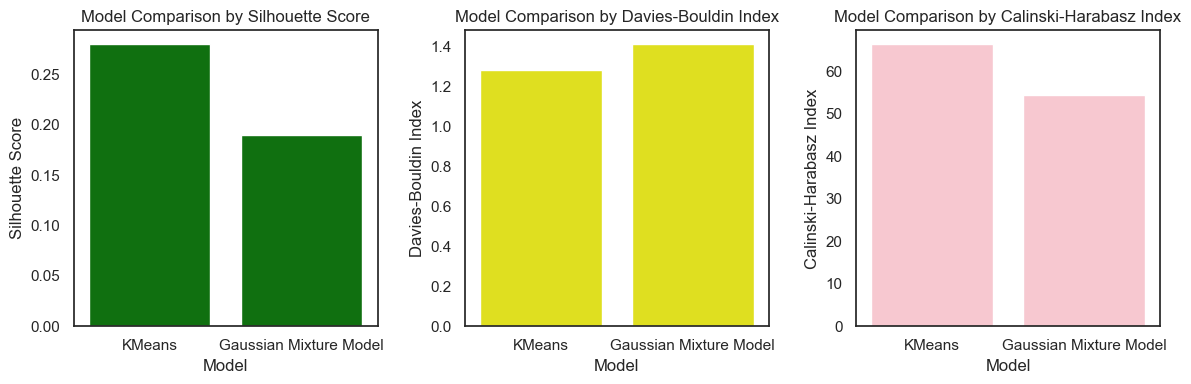

In [220]:
model = ['KMeans', 'Gaussian Mixture Model']
sil = [0.28, 0.19]
db = [1.28, 1.41]
ch = [66.23, 54.36]
sil_df = pd.DataFrame({'Model': model, 'Silhouette Score': sil}).sort_values(by='Silhouette Score', ascending=False)
db_df = pd.DataFrame({'Model': model, 'Davies-Bouldin Index': db}).sort_values(by='Davies-Bouldin Index', ascending=True)
ch_df = pd.DataFrame({'Model': model, 'Calinski-Harabasz Index': ch}).sort_values(by='Calinski-Harabasz Index', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(12,4,))

sns.barplot(data=sil_df, x='Model', y='Silhouette Score', ci=None, color='green', ax=axes[0])
axes[0].set_title('Model Comparison by Silhouette Score')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Silhouette Score')

sns.barplot(data=db_df, x='Model', y='Davies-Bouldin Index', ci=None, color='yellow', ax=axes[1])
axes[1].set_title('Model Comparison by Davies-Bouldin Index')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Davies-Bouldin Index')

sns.barplot(data=ch_df, x='Model', y='Calinski-Harabasz Index', ci=None, color='pink', ax=axes[2])
axes[2].set_title('Model Comparison by Calinski-Harabasz Index')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Calinski-Harabasz Index')

plt.tight_layout()
plt.show()